# Lecture: SARSA and Q-learning for Cliff walking

We look again at the `cliff walking` problem from the lecture and use the ``cliff-walking-v0`` environment provided by gymnasium. The problem is an episodic, non-discounted 4x12 gridworld that has a cliff in the bottom row. According to the figure, the agent receives one hundred minus points when crossing the cliff and the episode ends.
The agent starts in the bottom left-hand corner (coordinates [0, 3]) and aims to reach the bottom right-hand corner (coordinates [11, 3]). In each time step, the agent gets a -1 reward.

<img src="images/cliff-walk-theory.png" alt="Drawing" style="width: 600px;"/>

Simulating the environment yields the following visualization from gymnasium.

<img src="images/cliff-walk-gym.jpg" alt="Drawing" style="width: 400px;"/>

## Task 1

Load the gymnasium environment and view the possible states, actions and their coding within the environment. What is the observation and action space? How are the actions encoded?

In [1]:
import gymnasium as gym

env  = gym.make('CliffWalking-v0', render_mode='human')

observation, prob = env.reset()

n_times = 20

for i in range(n_times):

    action = env.action_space.sample()

    observation, reward, terminated, truncated, info = env.step(action)

    env.render()

    if terminated or truncated:
        env.reset() 

env.close()

## Task 2

With the given signature ``sarsa()`` of the template in ``cliff_walk_agent.py``, implement the on-policy SARSA algorithm to find the optimal path from the start to the end point. To do this, implement an epsilon greedy policy by reducing its epsilon for each episode according to
\begin{align*}
			\varepsilon_{k+1} = \max\left( \varepsilon_k \cdot \varepsilon_{\text{decay}}, 0.01 \right)
\end{align*}
where $\varepsilon_{\text{decay}}$ is the adjustment rate of $\varepsilon$. You can set $l=0.99$ as the default value here.

Test your code with the ``run_episode()`` method. Note that within the run_episode method an $\epsilon$-greedy policy is implemented! The default value for $\epsilon$ is $0$ here.

In [3]:
from cliff_walk_agent_sol import CliffWalkAgent
import gymnasium as gym

# initialize the agent
agent = CliffWalkAgent(gamma = 1.0)

# for control rendering should be deactivated due to performance reasons
env  = gym.make('CliffWalking-v0')

Q_sarsa, rewards = agent.sarsa(env, alpha=0.1,  epsilon=1, eps_decay=0.99, n_episodes=500)

env  = gym.make('CliffWalking-v0', render_mode = 'human')

rewards = agent.run_episode(env, Q_sarsa)

env.close()

## Task 3

Implement now Q-learning in the ``cliff_walk_agent.py``. Test the method as well with the ``run_episde()`` method.


In [4]:
from cliff_walk_agent_sol import CliffWalkAgent
import gymnasium as gym

# initialize the agent
agent = CliffWalkAgent(gamma = 1.0)

# for control rendering should be deactivated due to performance reasons
env  = gym.make('CliffWalking-v0')

Q_qlearning, rewards = agent.qlearning(env, alpha=0.1,  epsilon=1, eps_decay=0.99, n_episodes=500)

env  = gym.make('CliffWalking-v0', render_mode = 'human')

rewards = agent.run_episode(env, Q_qlearning)

env.close()

## Task 4

Run both algorithms with the following parameters ($\alpha=0.1, \varepsilon= 0.1, \varepsilon_{\text{decay}}=1., n_{\text{episodes}}=500$) and visualise the respective rewards over the episodes.	Average the results over 100 evaluations and interpret the results, i.e. the averaged rewards over the 100 evaluations and the final trajectories of individual runs after 500 episodes of the Sarsa and the Q-learning algorithm.

In [5]:
import gymnasium as gym
import numpy as np

agent = CliffWalkAgent(gamma = 1.0)
env  = gym.make('CliffWalking-v0')

runs = 100
avg_rew_sarsa = np.zeros(500)
avg_rew_q = np.zeros(500)
for go in range(runs):
    Q_sarsa, reps_sarsa = agent.sarsa(env, alpha = 0.1, epsilon = .1, eps_decay=1., n_episodes=500)
    Q_q, reps_q = agent.qlearning(env, alpha = 0.1, epsilon = .1, eps_decay=1., n_episodes=500)
    #rewards = run_episode(env, Q)
    avg_rew_sarsa += reps_sarsa 
    avg_rew_q += reps_q

avg_rew_sarsa = np.array(avg_rew_sarsa)/runs
avg_rew_q = np.array(avg_rew_q)/runs

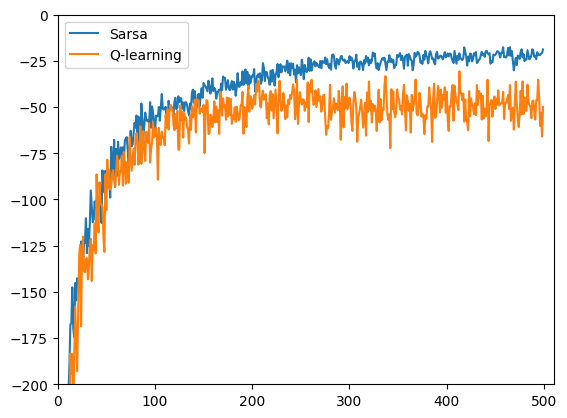

In [6]:
import matplotlib.pyplot as plt

plt.Figure()
plt.plot(avg_rew_sarsa, label='Sarsa')
plt.plot(avg_rew_q, label='Q-learning')
plt.xlim(0,510)
plt.ylim(-200, 0)
plt.legend()
plt.show()